# Orbital Path Analysis for Satelites
## Sean Meehan
### [SeanDMeehan.github.io](https://seandmeehan.github.io)
This project is concerned with the orbital paths of satelites. The overall goal is to use orbital path data to accurately predict the error in the projected orbital path of a given satelite. In order to make these predictions, we will need information about the position and velocity of satelites, as well as some information about the broader goings on of outer space. To get this information, we will use the following two datasets.
 * The first and most important dataset we will be working with during this project is from [Space-Track.org](https://www.space-track.org). This is satelite orbital data consitisting of Two Line Elements(TLEs). A TLE is an encoding of information about the position and velocity of a satelite at a given time that follows a specific protocol to structure the data. We will discuss this structure when parsing the TLEs. Our particular dataset is a collection of TLEs from several satelites over a specific date range. We are interested in this data for the several reasons. We will be able to reconstruct the past orbital paths and predict the future orbital paths of the satelites in the data. Looking at these paths we can ask and hope to answer the following questions:
     - Can we classify satellites into particular orbital regimes?
     - How fast does error grow in the projected path of a satelite?
     - Can we use some kind of model to predict the error of a projected orbit more accurately than traditional error propogation methods?
     - Can we statistically detect when a satellite makes a maneuver?
 * The second, supplementary dataset we will use is a solar weather dataset from _______. This contains information about solar weather such as solar flares and coronal mass ejections from a similar date range as the satelite data. We can use this dataset to address some additional questions:
     - What is the effect of different types of solar weather on satelite orbits?
     - Can we statistically distinguish between maneuvers and the effect of solar weather satelites?
     - Can we incorporate solar weather effects into our error prediction model?
Using this dataset we plan to use the following workflow to adress some of our questions:
1. Load and Process TLE Data: this step will consist of querying the Space-Track API to get historical TLE data, decoding this TLE data into a useful format, and calculating orbital path projections, error, ...etc.
2. Exploratory Data Analysis: we will explore the transfromed data in various ways to see in what ways we can use the data answer the questions above.
3. Answer Questions: several of the questions above are close ended. For instance, can we statistically detect when a satellite makes a manuever? We will adress these close ended questions first.
4. Create Models: several of our research questions deal with creating models. In this section of the project, we will create, train, and test these models.

## Load and Process TLE Data
In this section of the project we need to retrieve our data and process it to get it into a usable form. This will involve querying the Space-Track API and pulling the data, decoding the TLEs according to the TLE protocol, and deriving several features from this data. We will discuss these steps more in depth when come upon them. First things first, we install and import our modules.

In [18]:
!pip install sgp4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 3.9 MB/s eta 0:00:00a 0:00:01


In [19]:
import requests
from datetime import datetime, timedelta
import time
import pandas as pd
from sgp4.api import Satrec, jday
import matplotlib.pyplot as plt

### Query the Space-Track API
In order to access this data, you must go to Space-Track.com and make an account with them. Then, you can use their rest API. The API documentation can be found [here](https://www.space-track.org/documentation?utm_source=chatgpt.com). We have structured our query to get TLE data for every publically available satelite one day at a time. We then send a series of seven API calls to get seven days worth of data. This is to avoid an error that this API throws if you request too much data at a single time.

In [6]:
# You may use this password but you really should make your own and replace this line
USERNAME = "sean.meehan.misc@gmail.com"
PASSWORD = "PASSWORDpasswordPASSWORD"
# We want seven days of data
n_days = 7
# Write to a .txt file in the data folder
OUTPUT_FILE = f"payload_tles_last_{X_DAYS}_days.txt"
# Define relevant urls
login_url = "https://www.space-track.org/ajaxauth/login"
base_url = "https://www.space-track.org/basicspacedata/query/"
# FInd start and end dates
end_date = datetime.utcnow()
start_date = end_date - timedelta(days=n_days)
# Open request session
with requests.Session() as session:
    # Authenticate with API
    login_response = session.post(
        login_url,
        data={"identity": USERNAME, "password": PASSWORD}
    )
    login_response.raise_for_status()
    print("Login successful")
    # Make our series of requests
    with open(OUTPUT_FILE, "w") as outfile:
        current_date = start_date       
        while current_date < end_date:
            next_date = current_date + timedelta(days=1)
            start_str = current_date.strftime("%Y-%m-%d")
            end_str = next_date.strftime("%Y-%m-%d")
            query = (
                base_url +
                "class/gp_history/"
                "OBJECT_TYPE/PAYLOAD/"
                "DECAY_DATE/null-val/"
                f"EPOCH/{start_str}--{end_str}/"
                "orderby/NORAD_CAT_ID,EPOCH asc/"
                "format/tle"
            )
            print(f"Requesting {start_str} to {end_str}")
            response = session.get(query)
            if response.status_code == 200:
                outfile.write(response.text)
                print("  Success")
            else:
                print(f"  Failed: {response.status_code}")
                print(response.text[:500])
            # Wait to give time for servers to refresh ( this avoids another error)
            time.sleep(2)
            #iterate date
            current_date = next_date
print(f"\nAll data saved to {OUTPUT_FILE}")

Login successful
Requesting 2026-02-23 to 2026-02-24
  Success
Requesting 2026-02-24 to 2026-02-25
  Success
Requesting 2026-02-25 to 2026-02-26
  Success
Requesting 2026-02-26 to 2026-02-27
  Success
Requesting 2026-02-27 to 2026-02-28
  Success
Requesting 2026-02-28 to 2026-03-01
  Success
Requesting 2026-03-01 to 2026-03-02
  Success

All data saved to payload_tles_last_7_days.txt


### Process TLEs

We now have a text file full of thousands of raw TLE data. We want to get this into a more managable form, so we must do some processing. Ideally, we would load this directly into pandas, but unfortunately TLEs take up two lines each in the .txt file and the spacing of line 1 and line 2 is not the same. The format of a TLE is given below. Some TLEs have an optional line 0; ours do not. The format of a TLE is described [here](https://celestrak.org/norad/documentation/tle-fmt.php?utm_source=chatgpt.com).

```
Line 1: Orbital Metadata
1 NNNNNU YYNNN.NNNNNNNN  .00001234  00000-0  34567-4 0  9991
| |     |    |             |          |   | |      |
| |     |    |             |          |   | |      Checksum
| |     |    |             |          |   | Ephemeris type
| |     |    |             |          |   Element set number
| |     |    |             BSTAR drag term
| |     |    Second derivative of mean motion
| |     First derivative of mean motion
| International Designator (YYNNNXXX)
NORAD Catalog Number
Line Number

Line 2: Orbital Elements
2 NNNNN i.iiii RAAN.xxxxx eeeeeee w.www M.MMMM MM.MMMMMMMMM
| |      |       |     |       |      |        |
| |      |       |     |       |      |        Revolution number
| |      |       |     |       |      Mean Motion (rev/day)
| |      |       |     | Argument of Perigee (deg)
| |      |       |     Mean Anomaly (deg)
| |      |       Eccentricity (decimal implied)
| |      RAAN (deg)
| Inclination (deg)
NORAD Catalog Number
Line Number (2)
```

To solve the issue of loading this into pandas, we can use the above diagram to help us utilize the built in function `from_records()`. We can define a list of records by parsing the .txt files in base python, and then feed this into pandas. We will keep most of the TLE entries. We are dropping the line numbers, the checksums, and the international designator fields. We are keeping a full version of the TLE in each row of th df because it will help us to easily use the python module `sgp4` later on.

In [51]:
# Define filename
filename = "payload_tles_last_7_days.txt"
records = []
# Open file and load raw text
with open(filename) as f:
    lines = [line.rstrip("\n") for line in f]
#Loop over text two lines at a time
for i in range(0, len(lines), 2):
    line1 = lines[i]
    line2 = lines[i+1]
    record = {
        # Select the fields of the TLEs that we want for out dataframe
        "norad_id": line1[2:7],
        "classification": line1[7],
        "epoch": line1[18:32],
        "n_dot": line1[33:43],
        "n_ddot": line1[44:52],
        "bstar": line1[53:61],
        "ephem_type": line1[62],
        "elset_number": line1[64:68],      
        "inclination": line2[8:16],
        "raan": line2[17:25],
        "eccentricity": line2[26:33],
        "arg_perigee": line2[34:42],
        "mean_anomaly": line2[43:51],
        "mean_motion": line2[52:63],
        "raw_text": (line1, line2)
    }
    
    records.append(record)
# Feed records into pandas
df_tle = pd.DataFrame.from_records(records)
print(df_tle.head())

  norad_id classification           epoch       n_dot    n_ddot     bstar  \
0        5              U  26054.04666782   .00000128   00000-0   16796-3   
1    00005              U  26054.04666783   .00000128   00000-0   16796-3   
2    00011              U  26054.29444530   .00000657   00000-0   34495-3   
3       11              U  26054.46221720   .00000649   00000-0   34068-3   
4    00011              U  26054.54610263   .00000648   00000-0   34007-3   

  ephem_type elset_number inclination      raan eccentricity arg_perigee  \
0          0          999     34.2498  306.5821      1838029    343.7973   
1          0          999     34.2498  306.5821      1838029    343.7973   
2          0          999     32.8638  156.1300      1446014    128.7736   
3          0          999     32.8638  155.4951      1446009    129.7282   
4          0          999     32.8638  155.1777      1446002    130.2058   

  mean_anomaly  mean_motion                                           raw_text  

Now that we have our dataframe of satelite data, we wish to make some orbital path predcitions. We will make more sophisticated predictions later on in the project, but for the time being, we will use the python package `sgp4`. The documentation for this module can be found [here](https://pypi.org/project/sgp4/?utm_source=chatgpt.com). We will use this module to predict the position and velocity of each satelite at the timestamp of the next TLE associated with that satelite. This will allow us to calculate the error associated with this prediction, which is what we seek to analyze.

In [56]:
# We create a datetime variable to use with spg4. This function converts epoch time to datetime
def parse_epoch(epoch_str):
    year = int(epoch_str[:2])
    year += 2000 if year < 57 else 1900  # TLE convention
    day_of_year = float(epoch_str[2:])
    dt = datetime(year, 1, 1) + pd.to_timedelta(day_of_year - 1, unit='D')
    return dt
# Copy the df
df_tle = df_tle.copy()
# Create our new datetime column
df_tle['epoch_dt'] = df_tle['epoch'].apply(parse_epoch)
# Sort by satellite and epoch
df_sorted = df_tle.sort_values(['norad_id', 'epoch_dt']).reset_index(drop=True)
predictions = []
# Iterate over the groups we just created
for norad_id, group in df_sorted.groupby('norad_id'):
    group = group.reset_index(drop=True)
    for i in range(len(group) - 1):
        current = group.loc[i]
        next_tle = group.loc[i + 1]
        # We create a satelite object in satrec for each TLE
        line1, line2 = current['raw_text']
        sat = Satrec.twoline2rv(line1, line2)
        # Perdict path out to next TLE epoch
        target_time = next_tle['epoch_dt']
        jd, fr = jday(target_time.year, target_time.month, target_time.day,
                      target_time.hour, target_time.minute,
                      target_time.second + target_time.microsecond*1e-6)
        e, r_pred, v_pred = sat.sgp4(jd, fr)
        
        # Find the real position of the satelite from the next TLE
        next_line1, next_line2 = next_tle['raw_text']
        sat_next = Satrec.twoline2rv(next_line1, next_line2)
        jd_next, fr_next = jday(target_time.year, target_time.month, target_time.day,
                                target_time.hour, target_time.minute,
                                target_time.second + target_time.microsecond*1e-6)
        e, r_actual, _ = sat_next.sgp4(jd_next, fr_next)
        # Calculate error in euclidean distance
        error_km = ((r_pred[0]-r_actual[0])**2 +
                    (r_pred[1]-r_actual[1])**2 +
                    (r_pred[2]-r_actual[2])**2) ** 0.5
        # Combine with our current dataframe 
        pred_row = current.to_dict()
        pred_row.update({
            'pred_x_km': r_pred[0],
            'pred_y_km': r_pred[1],
            'pred_z_km': r_pred[2],
            'pred_vx_kms': v_pred[0],
            'pred_vy_kms': v_pred[1],
            'pred_vz_kms': v_pred[2],
            'position_error_km': error_km
        })
        predictions.append(pred_row)
df_tle = pd.DataFrame(predictions)
df_tle.head()

,norad_id,classification,epoch,n_dot,n_ddot,bstar,ephem_type,elset_number,inclination,raan,...,raw_text,epoch_dt,pred_x_km,pred_y_km,pred_z_km,pred_vx_kms,pred_vy_kms,pred_vz_kms,position_error_km,delta_days
0,5,U,26054.04666782,.00000128,00000-0,16796-3,0,999,34.2498,306.5821,...,(1 5U 58002B 26054.04666782 .00000128 ...,2026-02-23 01:07:12.099648,3676.748075,-6006.777401,-0.038816,5.865211,3.367742,4.605323,0.144430,NaN
1,5,U,26055.70289653,.00000131,00000-0,17540-3,0,999,34.2479,301.4702,...,(1 5U 58002B 26055.70289653 .00000131 ...,2026-02-24 16:52:10.260192,3339.316345,-6189.600812,0.016352,6.000573,3.136273,4.611477,0.097571,1.656229
2,5,U,26056.71504046,.00000129,00000-0,17525-3,0,999,34.2471,298.3463,...,(1 5U 58002B 26056.71504046 .00000129 ...,2026-02-25 17:09:39.495744,2995.600812,-6359.819211,-0.131022,6.122115,2.897159,4.613275,0.160928,1.012144
3,5,U,26057.72718522,.00000154,00000-0,20819-3,0,999,34.2461,295.2221,...,(1 5U 58002B 26057.72718522 .00000154 ...,2026-02-26 17:27:08.803008,2581.974512,-6544.555108,-0.038923,6.247180,2.606321,4.609538,0.086491,1.012145
4,5,U,26058.92335576,.00000170,00000-0,23153-3,0,999,34.2452,291.5298,...,(1 5U 58002B 26058.92335576 .00000170 ...,2026-02-27 22:09:37.937664,2323.054934,-6649.527116,-0.086698,6.314185,2.422850,4.604067,0.137630,1.196171


Now that we have this data we might want to keep it for the future, so we can write it to a .csv file.

In [61]:
df_tle.to_csv("processed_tle_7_days.csv")

### Exploratory Data Analysis

Now that we have created a managable(ish) dataframe, we can do some exploratory data analysis on the error. We start with summary stats.

In [57]:
print(df_tle['position_error_km'].describe())

count    397393.000000
mean          5.310179
std          63.428451
min           0.000000
25%           0.008838
50%           0.160741
75%           1.553893
max        8668.574712
Name: position_error_km, dtype: float64


No we wish to see the distribution of the prediction errors.

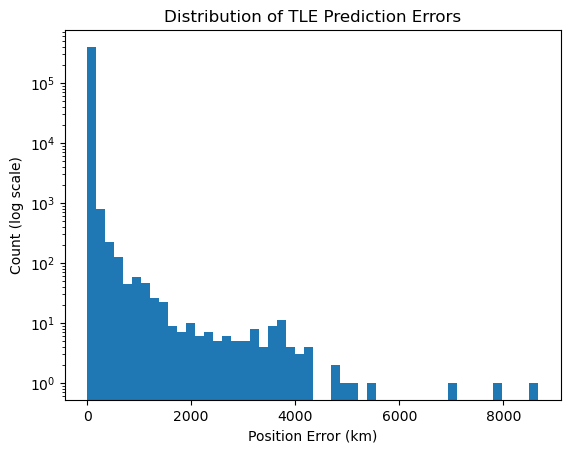

In [60]:
plt.hist(df_tle['position_error_km'], bins=50)
plt.yscale('log')   # Log scale for counts
plt.xlabel('Position Error (km)')
plt.ylabel('Count (log scale)')
plt.title('Distribution of TLE Prediction Errors')
plt.show()

One of our main questions is how does the error grow over time. A scatter plot of predictions error vs time is a good way to see this.

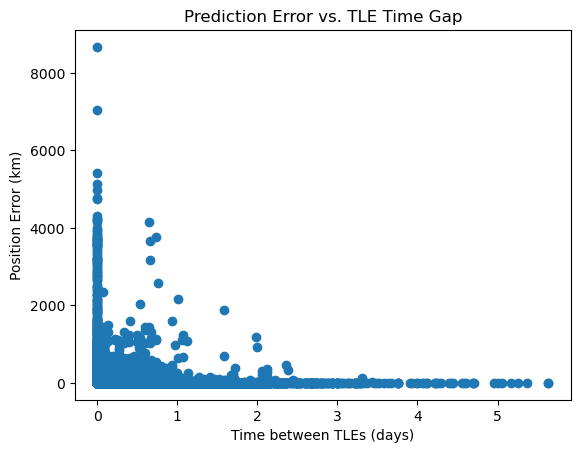

In [64]:
df_tle['delta_days'] = df_tle.groupby('norad_id')['epoch_dt'].diff().dt.total_seconds() / 86400
plt.scatter(df_tle['delta_days'], df_tle['position_error_km'])
plt.xlabel('Time between TLEs (days)')
plt.ylabel('Position Error (km)')
plt.title('Prediction Error vs. TLE Time Gap')
plt.show()